# TFM — 03. Feature Engineering: Accidentes de tráfico en Madrid (2012-2018)
**Autora:** Meritxell Abellan Collado

## Contexto y objetivo de este notebook

En el notebook anterior (`02_Preprocesado.ipynb`) se dejó el dataset limpio a nivel accidente. Este TFM aborda dos preguntas de investigación complementarias, que comparten el mismo dataset y el mismo target (`GRAVE`) pero difieren en qué información pueden utilizar:

**Pregunta 1 — Triaje operativo:** *¿Es posible anticipar, con la información disponible en el momento del aviso de un accidente de tráfico en Madrid (ubicación, momento, condiciones meteorológicas, tipo de vía y tipo de siniestro), la probabilidad de que resulte grave, con el fin de apoyar la priorización de recursos de emergencia (SAMUR / Policía Municipal / Emergencias 112)?*

**Pregunta 2 — Prevención vial:** *¿Qué factores — de lugar, momento, tipo de vía, tipo de siniestro y perfil de las personas implicadas — se asocian con una mayor gravedad, con el fin de informar campañas de prevención vial dirigidas (focalizadas por distrito, franja horaria o rango de edad)?*

La diferencia entre ambas no es de detalle: condiciona qué variables puede usar cada una. La Pregunta 1 exige que toda variable esté disponible **en el momento del aviso** — un modelo que use el perfil demográfico de los implicados no sería desplegable en producción, por bien que prediga en retrospectiva. La Pregunta 2 no tiene esa restricción, porque diseñar una campaña de prevención no requiere predecir nada en tiempo real; de hecho, el perfil de las personas implicadas es precisamente donde reside gran parte de la señal más útil para la prevención.

Este notebook construye **dos matrices de diseño**, una por pregunta:

| Matriz | Variables que usa | Responde a | Para qué sirve |
|---|---|---|---|
| **`FEATURES_OPERATIVO`** | Solo las disponibles en el aviso (lugar, momento, clima, tipo de vía/accidente/vehículo) + agregados históricos de distrito | Pregunta 1 | Modelo real, desplegable en producción para apoyar el despacho de recursos |
| **`FEATURES_REFERENCIA`** | Todo lo anterior + variables de persona (edad de riesgo, nº de implicados, nº de víctimas) | Pregunta 2 | No es desplegable, pero es la base del análisis explicativo (SHAP) en `04_Modelizacion.ipynb`, y también cuantifica cuánto se "pierde" frente al operativo — dos usos de la misma matriz, no dos matrices distintas |


## 0. Carga de datos

**Por qué se parte de `train_temporal` / `test_temporal` y no del dataset completo:** cualquier estadístico que se calcule a partir de aquí (medias históricas, categorías de referencia, etc.) tiene que aprenderse **solo con `train`** y aplicarse después a `test`, exactamente igual que se haría con datos nuevos en producción. Trabajar ya con los dos conjuntos separados desde la primera celda evita el error más habitual en este tipo de proyecto: calcular una estadística con todo el dataset y filtrar sin querer información del futuro hacia el pasado.

## 1. Recuperar señal de las variables de persona sin romper la disponibilidad temporal

Aunque no se pueda saber, en el aviso de *este* accidente, si habrá un peatón implicado, sí se puede saber el **perfil histórico** de esa zona: ¿qué proporción de accidentes pasados en ese distrito implicaban un peatón o una moto? Esto es información legítima en el momento del aviso, porque no describe el accidente actual — describe el patrón histórico del contexto (el mismo tipo de dato que usaría un sistema real de despacho de emergencias con acceso a series históricas de siniestralidad).

**Por qué se usa suavizado (`m=50`) y no la media simple por grupo:** un distrito con pocos accidentes podría tener, por puro azar, una tasa de gravedad histórica extrema (0% o 100%) que no generalizaría bien. El suavizado tipo Bayes empírico combina la media del grupo con la media global, ponderando por el tamaño de la muestra: grupos grandes se quedan casi con su propia media; grupos pequeños se acercan a la media global. Es la misma idea que un *target encoding* clásico, pero evitando que categorías con pocos casos introduzcan ruido.

**Por qué se agrega por `DISTRITO`** y no por `TIPO_VIA` o `TIPO ACCIDENTE`: esas dos variables se van a codificar más abajo con *one-hot* directamente, así que un agregado histórico calculado sobre el mismo grupo sería redundante (cada fila del agregado sería una función exacta de las columnas *one-hot*, sin aportar información nueva). `DISTRITO` no se codifica con *one-hot* en este proyecto (ver sección 3), así que aquí sí aporta señal genuina.


In [ ]:
import pandas as pd
import sys
sys.path.append('..')
from src.pipelines.pipeline_produccion import PipelineAccidentes

df_raw = pd.read_excel('../data/raw/accidentes-trafico.xlsx')
df_raw['FECHA'] = pd.to_datetime(df_raw['FECHA'])

df_historico_raw = df_raw[df_raw['FECHA'].dt.year <= 2017].copy()
df_nuevo_raw = df_raw[df_raw['FECHA'].dt.year == 2018].copy()

pipe = PipelineAccidentes(m_target_encoding=50)
train = pipe.fit(df_historico_raw)      # ajusta TODO y devuelve train ya con OOF aplicado
test = pipe.transform(df_nuevo_raw)     # aplica lo aprendido, sin OOF (no hace falta en datos nunca vistos)

FEATURES_OPERATIVO = pipe.features_operativo
FEATURES_REFERENCIA = pipe.features_referencia

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Features operativo: {len(FEATURES_OPERATIVO)} | Features referencia: {len(FEATURES_REFERENCIA)}')


Train: (58095, 58) | Test: (10678, 58)
Features operativo: 39 | referencia: 43


No hay categorías de `DISTRITO` en `test` que no existieran ya en `train` (0 nulos tras aplicar el mapeo), pero el `.fillna(global_mean)` queda como salvaguarda: si en el futuro apareciera un distrito nuevo (poco probable), se le asignaría la media global en vez de un nulo que rompería el modelo.

## 2. Variables temporales: codificación cíclica

`HORA` (0-23) y `MES` (1-12) son variables cíclicas: la hora 23 está tan cerca de la 0 como la 22 lo está de la 23, pero un modelo que reciba `HORA` como un número lineal no lo sabe — para él, 0 y 23 están todo lo lejos posible. Lo mismo pasa con diciembre (12) y enero (1). Se codifican con seno/coseno, la forma estándar de representar periodicidad sin imponer un salto artificial en la frontera del ciclo.


In [2]:
# HORA_SIN/COS ya se calcularon dentro de pipe.fit()/transform() -- aquí solo se verifica
train[['HORA', 'HORA_SIN', 'HORA_COS']].drop_duplicates().sort_values('HORA')


,HORA,HORA_SIN,HORA_COS
34,0,0.000000e+00,1.000000e+00
132,1,2.588190e-01,9.659258e-01
0,2,5.000000e-01,8.660254e-01
134,3,7.071068e-01,7.071068e-01
12,4,8.660254e-01,5.000000e-01
3,5,9.659258e-01,2.588190e-01
295,6,1.000000e+00,6.123234e-17
4,7,9.659258e-01,-2.588190e-01
36,8,8.660254e-01,-5.000000e-01
39,9,7.071068e-01,-7.071068e-01


> **Nota:** `ES_FINDE`, ya construida en el preprocesado, se mantiene como variable binaria adicional — no es redundante con `MES_SIN/COS`, describe un patrón semanal, no anual. `AÑO`, `FECHA`, `RANGO HORARIO` y `DIA SEMANA` (las versiones sin procesar) se descartan como features: `AÑO` porque en 2018 (test) el modelo vería un valor que nunca estuvo en el rango de entrenamiento (2012-2017), lo que puede confundir a algunos algoritmos con una variable que en la práctica es solo un identificador temporal, no una causa; y `RANGO HORARIO`/`DIA SEMANA` porque ya están representadas por sus versiones numéricas/cíclicas.

## 3. Codificación de categóricas

No todas las categóricas se codifican igual — la elección depende de la cardinalidad y de si ya existe una alternativa mejor:

- **`TIPO_VIA`** (9 categorías) y **`TIPO ACCIDENTE`** (11 categorías): cardinalidad baja, sin orden natural entre categorías → **one-hot**. Es la opción más simple e interpretable, y no asume ninguna relación de orden o distancia entre "autovía" y "calle" que no exista en realidad.
- **`DISTRITO`** (21 categorías): ya se ha usado en la sección 1 como base de los agregados históricos suavizados. Añadir además un *one-hot* de 20 columnas sería redundante y aumentaría mucho la dimensionalidad para lo que aporta — se deja representado únicamente a través de esos 3 agregados.



In [3]:
print(f'Categoría de referencia TIPO_VIA: {pipe.ref_via} '
      f'({(train["TIPO_VIA"] == pipe.ref_via).mean()*100:.1f}% de los accidentes de train)')
print(f'Categoría de referencia TIPO ACCIDENTE: {pipe.ref_acc} '
      f'({(train["TIPO ACCIDENTE"] == pipe.ref_acc).mean()*100:.1f}% de los accidentes de train)')

nuevas_via = set(test['TIPO_VIA'].unique()) - set(train['TIPO_VIA'].unique())
nuevas_acc = set(test['TIPO ACCIDENTE'].unique()) - set(train['TIPO ACCIDENTE'].unique())
print('Categorías de TIPO_VIA en test no vistas en train:', nuevas_via if nuevas_via else 'ninguna')
print('Categorías de TIPO ACCIDENTE en test no vistas en train:', nuevas_acc if nuevas_acc else 'ninguna')


Categoría de referencia TIPO_VIA: CALLE (52.5% de los accidentes de train)
Categoría de referencia TIPO ACCIDENTE: COLISIÓN DOBLE (55.4% de los accidentes de train)
Categorías de TIPO_VIA en test no vistas en train: ninguna
Categorías de TIPO ACCIDENTE en test no vistas en train: ninguna


No hay categorías nuevas en `test`, así que no hace falta una estrategia especial para "categoría desconocida" — pero se deja la función preparada con `.reindex(..., fill_value=0)`, que asignaría ceros en todas las columnas *one-hot* (equivalente a la categoría de referencia) si algún día apareciera una categoría no vista, en vez de romper el pipeline.

In [4]:
cols_via = [c for c in train.columns if c.startswith('VIA_')]
cols_acc = [c for c in train.columns if c.startswith('ACC_')]
print(f'Columnas one-hot de TIPO_VIA (referencia = {pipe.ref_via}):', cols_via)
print(f'Columnas one-hot de TIPO ACCIDENTE (referencia = {pipe.ref_acc}):', cols_acc)


Columnas one-hot de TIPO_VIA (referencia = CALLE): ['VIA_AUTOVIA', 'VIA_AVENIDA', 'VIA_CARRETERA', 'VIA_GLORIETA', 'VIA_OTROS', 'VIA_PASEO', 'VIA_PLAZA', 'VIA_RONDA']
Columnas one-hot de TIPO ACCIDENTE (referencia = COLISIÓN DOBLE): ['ACC_ATROPELLO', 'ACC_CAÍDA BICICLETA', 'ACC_CAÍDA CICLOMOTOR', 'ACC_CAÍDA MOTOCICLETA', 'ACC_CAÍDA VEHÍCULO 3 RUEDAS', 'ACC_CAÍDA VIAJERO BUS', 'ACC_CHOQUE CON OBJETO FIJO', 'ACC_COLISIÓN MÚLTIPLE', 'ACC_OTRAS CAUSAS', 'ACC_VUELCO']


## 4. Meteorología y estado del firme

`CPFA_*` (condición meteorológica) y `CPSV_*` (estado del firme) llegaron del preprocesado como 6 y 6 columnas binarias independientes respectivamente. Antes de usarlas todas juntas, conviene comprobar algo que no es evidente a simple vista: ¿son en realidad categorías mutuamente excluyentes (es decir, un *one-hot* ya construido) camuflado en columnas sueltas?


In [5]:
CPFA_COLS = ['CPFA Granizo','CPFA Hielo','CPFA Lluvia','CPFA Niebla','CPFA Seco','CPFA Nieve']
CPSV_COLS = ['CPSV Mojada','CPSV Aceite','CPSV Barro','CPSV Grava Suelta','CPSV Hielo','CPSV Seca Y Limpia']

print('Suma de las 6 columnas CPFA por fila (¿sale casi siempre 1?):')
print(train[CPFA_COLS].sum(axis=1).value_counts())
print()
print('Suma de las 6 columnas CPSV por fila:')
print(train[CPSV_COLS].sum(axis=1).value_counts())

Suma de las 6 columnas CPFA por fila (¿sale casi siempre 1?):
1    58044
2       51
Name: count, dtype: int64

Suma de las 6 columnas CPSV por fila:
1    57693
0      288
2      110
3        4
Name: count, dtype: int64


Confirmado: en el 99.9% de los casos, exactamente una columna `CPFA_*` vale 1 (son mutuamente excluyentes) y algo similar ocurre con `CPSV_*`. Es decir, son un *one-hot* ya construido de dos variables categóricas ("condición meteorológica" y "estado del firme"), no seis variables binarias independientes. Usar las 6 columnas de cada grupo a la vez es exactamente la misma trampa de variable ficticia de la sección anterior — de hecho, se ve directamente en la matriz de correlación:


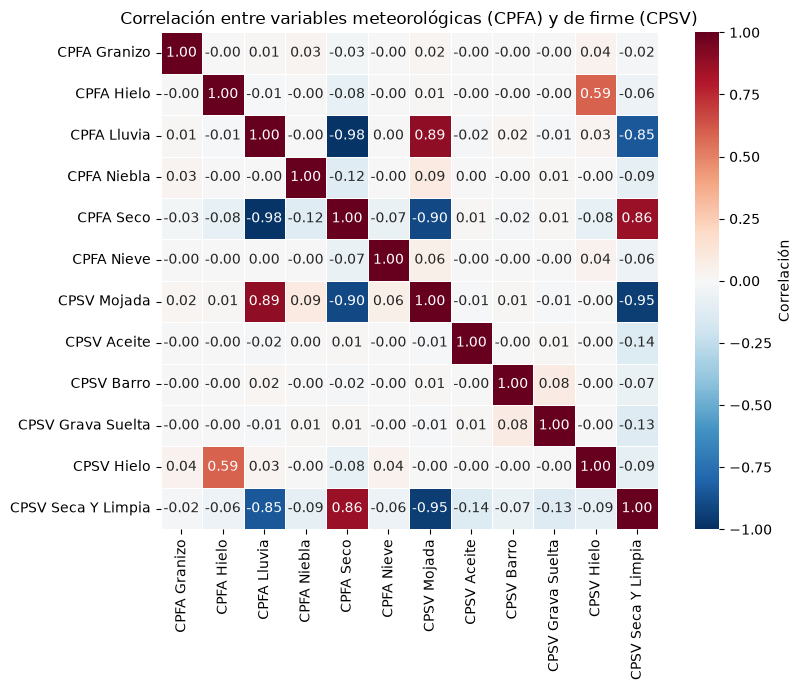

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_meteo = train[CPFA_COLS + CPSV_COLS].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_meteo, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlación'}, ax=ax)
ax.set_title('Correlación entre variables meteorológicas (CPFA) y de firme (CPSV)')
plt.tight_layout()
plt.savefig('../figures/10b_heatmap_condiciones.png', dpi=150, bbox_inches='tight')
plt.show()

`CPFA Lluvia` y `CPFA Seco` correlacionan -0.98: son casi opuestos exactos, como cabía esperar. **Se elimina la categoría de referencia de cada grupo** (`CPFA Seco` y `CPSV Seca Y Limpia`, las condiciones "normales" y más frecuentes), conservando solo las condiciones anómalas — su ausencia ya implica "condición normal", exactamente igual que con `TIPO_VIA`/`TIPO ACCIDENTE` en la sección anterior.


In [7]:
cpfa_a = [c for c in train.columns if c.startswith('CPFA ') and c in pipe.features_operativo]
cpsv_a = [c for c in train.columns if c.startswith('CPSV ') and c in pipe.features_operativo]
print('Variables meteorológicas conservadas:', cpfa_a)
print('Variables de firme conservadas:', cpsv_a)


Variables meteorológicas conservadas: ['CPFA Granizo', 'CPFA Hielo', 'CPFA Lluvia', 'CPFA Niebla', 'CPFA Nieve']
Variables de firme conservadas: ['CPSV Mojada', 'CPSV Aceite', 'CPSV Barro', 'CPSV Grava Suelta', 'CPSV Hielo']


## 5. Construcción de las dos matrices de diseño (operativo y referencia)

Con todo lo anterior ya calculado, se definen explícitamente qué columnas entran en cada matriz. Esta tabla es, en sí misma, la justificación de disponibilidad temporal de cada variable — es la pieza central que conecta este notebook con las dos preguntas de investigación del TFM: `FEATURES_OPERATIVO` para la Pregunta 1, `FEATURES_REFERENCIA` para la Pregunta 2.


In [8]:
print(f'Nº de features — modelo operativo:    {len(FEATURES_OPERATIVO)}')
print(f'Nº de features — modelo de referencia: {len(FEATURES_REFERENCIA)}')
print(f'Columnas extra en referencia: {FEATURES_REFERENCIA[len(FEATURES_OPERATIVO):]}')


Nº de features — modelo operativo:    39
Nº de features — modelo de referencia: 43
Columnas extra en referencia: ['INCLUYE_PEATON', 'INCLUYE_EDAD_RIESGO', 'N_PERSONAS_IMPLICADAS', 'N_VICTIMAS_LOG']


**Por qué `INCLUYE_PEATON` va solo al modelo de referencia y no al operativo, a pesar de estar correlacionada con `TIPO ACCIDENTE = ATROPELLO`:** en el aviso inicial se suele saber el tipo de accidente (de ahí que `ACC_ATROPELLO` sí esté en el operativo), pero confirmar que hay específicamente un peatón entre los implicados (y no, por ejemplo, un ciclista atropellado por error de clasificación, o más de una persona con roles distintos) es información que en la práctica se termina de confirmar cuando llegan los servicios — de ahí que se trate como variable de "referencia", no operativa, siguiendo el mismo criterio estricto que con el resto de variables de persona.

## 6. Verificación final: sin categorías nuevas, sin nulos, y colinealidad revisada en dos pasos

Antes de dar el dataset por bueno: (1) categorías nuevas, nulos y dimensiones; (2) un cribado amplio de pares de variables con correlación alta, sobre el conjunto final de `X_train_op`; (3) la confirmación rigurosa de si esos pares suponen un problema real, con VIF.


In [9]:
X_train_op, X_test_op = train[FEATURES_OPERATIVO].copy(), test[FEATURES_OPERATIVO].copy()
X_train_ref, X_test_ref = train[FEATURES_REFERENCIA].copy(), test[FEATURES_REFERENCIA].copy()
y_train, y_test = train['GRAVE'].copy(), test['GRAVE'].copy()

print('--- Nulos ---')
print('Train operativo:', X_train_op.isna().sum().sum(), '| Test operativo:', X_test_op.isna().sum().sum())
print('Train referencia:', X_train_ref.isna().sum().sum(), '| Test referencia:', X_test_ref.isna().sum().sum())

print()
print('--- Dimensiones ---')
print('Operativo:', X_train_op.shape, X_test_op.shape)
print('Referencia:', X_train_ref.shape, X_test_ref.shape)

assert list(X_train_op.columns) == list(X_test_op.columns), "Columnas operativo no coinciden entre train y test"
assert list(X_train_ref.columns) == list(X_test_ref.columns), "Columnas referencia no coinciden entre train y test"
print('Columnas de train y test alineadas para ambas matrices.')

--- Nulos ---
Train operativo: 0 | Test operativo: 0
Train referencia: 0 | Test referencia: 0

--- Dimensiones ---
Operativo: (58095, 39) (10678, 39)
Referencia: (58095, 43) (10678, 43)
Columnas de train y test alineadas para ambas matrices.


**Paso 2 — cribado amplio:** la Sección 4 ya corrigió la colinealidad *perfecta* entre `CPFA_*`/`CPSV_*` (la trampa de variable ficticia). Ahora se revisa, sobre el conjunto final de 39 variables operativas, si queda algún par con correlación alta que se nos haya escapado.


In [10]:
# --- Colinealidad: pares de variables con correlación absoluta > 0.6 ---
from src.pipelines.feature_engineering import pares_alta_colinealidad

pares_altos = pares_alta_colinealidad(X_train_op, umbral=0.6)
pares_altos

,var_1,var_2,correlacion
323,CPFA Lluvia,CPSV Mojada,0.890193
642,TASA_GRAVEDAD_HIST_DISTRITO,PCT_HIST_MOTO_DISTRITO,0.669165
641,TASA_GRAVEDAD_HIST_DISTRITO,PCT_HIST_PEATON_DISTRITO,0.605680


Quedan tres pares por encima de 0.6, y los tres tienen una explicación sustantiva razonable, no un error de codificación:

- **`CPFA Lluvia` / `CPSV Mojada` (0.89):** tiene sentido — cuando llueve, el firme suele estar mojado. Es una correlación real del mundo, no un artefacto.
- **`TASA_GRAVEDAD_HIST_DISTRITO` / `PCT_HIST_PEATON_DISTRITO` y `PCT_HIST_MOTO_DISTRITO` (0.64 / 0.71):** esperable, ya que los tres son agregados calculados sobre el mismo `DISTRITO` — comparten parte de la varianza por construcción, aunque cada uno capture un aspecto distinto (gravedad global vs. composición de peatones vs. composición de motos).

Ninguno llega al nivel de colinealidad *perfecta* (>0.95) visto en la sección 4 antes de corregirlo, así que no hace falta eliminar ninguna variable adicional.


**Paso 3 — confirmación rigurosa:** una correlación por pares, sin embargo, no basta para decidir si hay que tratar una variable — mide solo dos variables a la vez, no su relación con el conjunto completo. Se confirma con el VIF (*Variance Inflation Factor*), el test diseñado específicamente para eso: cuánto se puede predecir cada variable a partir de **todas las demás combinadas**. Regla habitual: VIF > 10 exige actuar, 5-10 es zona de vigilancia, < 5 no es problema.


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train_op.astype(float))  # necesario: sin constante, statsmodels calcula un R2 no centrado que infla artificialmente el VIF de variables con poca varianza relativa

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False)  # se descarta la fila de la constante, no es una variable real

vif_df.head(10)


**Resultado:** aunque el paso 2 señalaba tres correlaciones moderadas, ninguna se traduce en un VIF superior a 10 — no hay colinealidad real que requiera tratamiento. Las dos más altas (`CPFA Lluvia`, `CPSV Mojada`, ~5.2) quedan justo en el borde de la zona de vigilancia, coherente con ser las categorías más representadas entre meteorología/firme. Nótese que `CPFA Hielo`/`CPSV Hielo` (r=0.59 en el mapa de calor de la Sección 4) tiene VIF bajo (~1.56): su correlación por pares no se traduce en un problema real frente al conjunto completo de variables. No hace falta eliminar ni tratar ninguna variable por este motivo, ni siquiera si se usara la regresión logística como modelo final en vez de solo como referencia.


## 7. Guardado de artefactos

Se guardan las cuatro matrices y los dos vectores objetivo por separado.


In [11]:
import os

os.makedirs('../models', exist_ok=True)
pipe.save('../models/pipeline_produccion.joblib')

X_train_op.to_csv('../data/processed/features/X_train_operativo.csv', index=False)
X_test_op.to_csv('../data/processed/features/X_test_operativo.csv', index=False)
X_train_ref.to_csv('../data/processed/features/X_train_referencia.csv', index=False)
X_test_ref.to_csv('../data/processed/features/X_test_referencia.csv', index=False)
y_train.to_csv('../data/processed/features/y_train.csv', index=False)
y_test.to_csv('../data/processed/features/y_test.csv', index=False)

print('Ficheros guardados en ../data/processed/features/')
print(f'  X_train_operativo:  {X_train_op.shape}')
print(f'  X_train_referencia: {X_train_ref.shape}')

Pipeline guardado en ../models/pipeline_produccion.joblib
Ficheros guardados en ../data/processed/features/
  X_train_operativo:  (58095, 39)
  X_train_referencia: (58095, 43)


## Resumen de decisiones tomadas en este notebook

| # | Decisión | Por qué |
|---|---|---|
| 1 | Toda codificación se ajusta solo con `train` y se aplica después a `test` | Evitar fuga de información: en producción, el modelo nunca tendría acceso a estadísticos calculados con datos futuros |
| 2 | Agregados históricos suavizados (`m=50`) para `DISTRITO` sobre `GRAVE`, `INCLUYE_PEATON`, `INCLUYE_MOTO` | Recuperan parte de la señal de las variables de persona sin romper la disponibilidad temporal — es información de contexto histórico, no del accidente actual |
| 3 | `HORA` y `MES` codificadas en seno/coseno | Son variables cíclicas; una codificación lineal introduciría un salto artificial entre 23h/0h y diciembre/enero |
| 4 | `TIPO_VIA` y `TIPO ACCIDENTE` con *one-hot*, `DISTRITO` no | Cardinalidad baja y sin agregados históricos alternativos para las dos primeras; `DISTRITO` ya está representado vía los agregados de la decisión 2, un *one-hot* adicional sería redundante |
| 5 | Categoría de referencia = la más frecuente (`CALLE`, `COLISIÓN DOBLE`), no la primera alfabética | Coeficientes interpretables como "frente al caso más común" |
| 6 | Se detecta y corrige que `CPFA_*` / `CPSV_*` son en realidad un *one-hot* ya construido, y se elimina la categoría de referencia de cada grupo | Sin corregirlo, hay colinealidad casi perfecta (r=-0.98) que perjudicaría a cualquier modelo lineal |
| 7 | Variables de persona (`INCLUYE_PEATON`, `INCLUYE_EDAD_RIESGO`, `N_PERSONAS_IMPLICADAS`, `N_VICTIMAS_LOG`) solo en el modelo de **referencia**, nunca en el operativo | Son información posterior al accidente; incluirlas en el modelo operativo lo haría no desplegable en la práctica |
| 8 | Colinealidad moderada (0.6-0.9) que queda, se documenta pero no se corrige | Tiene explicación sustantiva real (lluvia↔firme mojado; agregados del mismo distrito); se traslada como advertencia al notebook de modelización para el caso de usar modelos lineales |
| 9 | El escalado de variables numéricas (necesario si se usa regresión logística con L2) se deja para `04_Modelizacion.ipynb`, ajustado solo con train, junto al resto de decisiones específicas del algoritmo | El escalado depende del modelo elegido, no del dataset — los modelos basados en árboles (candidato principal, dado el desbalanceo) no lo necesitan |

**Siguiente paso:** `04_Modelizacion.ipynb` — entrenar y comparar el modelo operativo y el de referencia (Pregunta 1: regresión logística con class_weight + Random Forest/Gradient Boosting, evaluados por discriminación y calibración), e interpretar los factores de riesgo del modelo de referencia con SHAP (Pregunta 2: análisis explicativo para prevención vial).
